In [93]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers

In [94]:
#load the dataset and print the head
data_path = '/content/drive/MyDrive/kc_house_data.csv'
house_df = pd.read_csv(data_path)
house_df.head()
#print(house_df)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000


In [95]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [96]:
#print the shape of dataset
house_df.shape

(21614, 21)

In [97]:
#count of the data
house_df.count()

id               21614
date             21614
price            21614
bedrooms         21614
bathrooms        21614
sqft_living      21614
sqft_lot         21614
floors           21614
waterfront       21614
view             21614
condition        21614
grade            21614
sqft_above       21614
sqft_basement    21614
yr_built         21614
yr_renovated     21614
zipcode          21614
lat              21614
long             21614
sqft_living15    21614
sqft_lot15       21614
dtype: int64

In [98]:
#describe the dataset
house_df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161400e+04,2.161400e+04,21614.000000,21614.000000,21614.000000,2.161400e+04,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000
mean,4.580205e+09,5.400911e+05,3.370871,2.114798,2079.894189,1.510650e+04,1.494286,0.007541,0.234293,3.409503,7.656843,1788.356528,291.537661,1971.004858,84.398353,98077.942491,47.560051,-122.213905,1986.523503,12768.096234
std,2.876534e+09,3.671190e+05,0.930050,0.770169,918.420011,4.141961e+04,0.539987,0.086515,0.766301,0.650818,1.175440,828.087051,442.584799,29.372760,401.670358,53.505246,0.138561,0.140830,685.388698,27303.599094
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219625e+05,3.000000,1.750000,1427.750000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471025,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230500,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068775e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [99]:
#column data types
house_df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [100]:
house_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000


In [101]:
#getting the registration year from the date
house_df['reg_year'] = house_df['date'].str[:4]
print(house_df['reg_year'])

0        2014
1        2014
2        2015
3        2014
4        2014
         ... 
21609    2014
21610    2015
21611    2014
21612    2015
21613    2014
Name: reg_year, Length: 21614, dtype: object


In [102]:
#convert reg_year to integer
house_df['reg_year'] = house_df['reg_year'].astype('int')
house_df.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
reg_year           int64
dtype: object

In [103]:
#create a new column called house_age
house_df['house_age'] = np.NaN

In [104]:
house_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,reg_year,house_age
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,NaN
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,NaN
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,NaN
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,NaN
4,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,NaN


In [105]:
#loop through the renovation column and find the age
for i,j in enumerate (house_df['yr_renovated']):
    if(j==0):
        house_df['house_age'][i] = house_df['reg_year'][i]-house_df['yr_built'][i]
    else:
        house_df['house_age'][i] = house_df['reg_year'][i]-house_df['yr_renovated'][i]

<ipython-input-105-a43af480d56b>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house_df['house_age'][i] = house_df['reg_year'][i]-house_df['yr_built'][i]
<ipython-input-105-a43af480d56b>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house_df['house_age'][i] = house_df['reg_year'][i]-house_df['yr_renovated'][i]


In [106]:
house_df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,reg_year,house_age
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,59.0
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,23.0
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,82.0
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,49.0
4,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,49.0


In [107]:
#remove the date values other than age
house_df.drop(['date','yr_built','yr_renovated','reg_year'], axis=1, inplace=True)
house_df.head()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,house_age
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,98178,47.5112,-122.257,1340,5650,59.0
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,98125,47.7210,-122.319,1690,7639,23.0
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,98028,47.7379,-122.233,2720,8062,82.0
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,98136,47.5208,-122.393,1360,5000,49.0
4,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,98136,47.5208,-122.393,1360,5000,49.0


In [108]:
#remove other irrelvent columns
house_df.drop(['id','zipcode','lat','long'], axis=1, inplace=True)
house_df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,sqft_living15,sqft_lot15,house_age
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1340,5650,59.0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1690,7639,23.0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,2720,8062,82.0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1360,5000,49.0
4,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1360,5000,49.0


In [109]:
house_df.shape

(21614, 15)

In [110]:
house_df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,sqft_living15,sqft_lot15,house_age
count,2.161400e+04,21614.000000,21614.000000,21614.000000,2.161400e+04,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000,21614.000000
mean,5.400911e+05,3.370871,2.114798,2079.894189,1.510650e+04,1.494286,0.007541,0.234293,3.409503,7.656843,1788.356528,291.537661,1986.523503,12768.096234,40.937309
std,3.671190e+05,0.930050,0.770169,918.420011,4.141961e+04,0.539987,0.086515,0.766301,0.650818,1.175440,828.087051,442.584799,685.388698,27303.599094,28.813029
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,399.000000,651.000000,-1.000000
25%,3.219625e+05,3.000000,1.750000,1427.750000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1490.000000,5100.000000,15.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1840.000000,7620.000000,37.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068775e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,2360.000000,10083.000000,60.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,6210.000000,871200.000000,115.000000


In [111]:
#remove all -1 values from the house_age
house_df = house_df[house_df['house_age']!=-1]
house_df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,sqft_living15,sqft_lot15,house_age
count,2.159600e+04,21596.000000,21596.000000,21596.000000,2.159600e+04,21596.000000,21596.000000,21596.000000,21596.000000,21596.000000,21596.000000,21596.000000,21596.000000,21596.000000,21596.000000
mean,5.401054e+05,3.370717,2.114408,2079.523199,1.511292e+04,1.493865,0.007548,0.233886,3.409844,7.656233,1788.194017,291.329181,1986.541443,12772.294175,40.972263
std,3.672379e+05,0.929764,0.770040,918.111315,4.143550e+04,0.539693,0.086551,0.765415,0.650982,1.175419,828.065982,442.302165,685.485153,27313.970523,28.799574
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,399.000000,651.000000,0.000000
25%,3.215000e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1490.000000,5100.000000,16.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1840.000000,7620.000000,37.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.069525e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,2360.000000,10083.250000,60.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,6210.000000,871200.000000,115.000000


In [112]:
#distribution plot for all columns
#for i in house_df.columns:
    #sns.displot(house_df[i])
    #plt.show()

In [113]:
#pairplot
#plt.figure()
#sns.pairplot(house_df)
#plt.show()

In [114]:
#heatmap
#plt.figure(figsize = (20,10))
#sns.heatmap(house_df.corr(), annot=True)
#plt.show()

In [115]:
#box plot for all columns
#for i in house_df.columns:
    #sns.boxplot(x=house_df[i])
    #plt.show()

In [116]:
house_df.drop('price', axis=1).head()
house_df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,sqft_living15,sqft_lot15,house_age
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1340,5650,59.0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1690,7639,23.0
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,2720,8062,82.0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1360,5000,49.0
4,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1360,5000,49.0


In [117]:
#split the dataframe into input X and output y
X = house_df.drop('price', axis=1)
y = house_df['price']

X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,sqft_living15,sqft_lot15,house_age
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1340,5650,59.0
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1690,7639,23.0
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,2720,8062,82.0
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1360,5000,49.0
4,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1360,5000,49.0


In [118]:
y.head()

0    221900.0
1    538000.0
2    180000.0
3    604000.0
4    604000.0
Name: price, dtype: float64

In [119]:
#Defining the model
model = keras.Sequential()
model.add(layers.Dense(14, activation='relu'))
model.add(layers.Dense(14, activation='relu'))
model.add(layers.Dense(14, activation='relu'))
model.add(layers.Dense(4, activation='relu'))
model.add(layers.Dense(1))

In [120]:
#optimizer is stochastic graident
model.compile(loss='mse', optimizer='adam', metrics=['mse','mae'])
# This builds the model for the first time:
history = model.fit(X, y, validation_split=0.33, batch_size=32, epochs=20)

Epoch 1/20
453/453 [==============================] - 3s 5ms/step - loss: 340846870528.0000 - mse: 340846870528.0000 - mae: 447735.4062 - val_loss: 296175730688.0000 - val_mse: 296175730688.0000 - val_mae: 411181.3438
Epoch 2/20
453/453 [==============================] - 2s 4ms/step - loss: 208328376320.0000 - mse: 208328376320.0000 - mae: 302891.4062 - val_loss: 98478514176.0000 - val_mse: 98478514176.0000 - val_mae: 193669.0781
Epoch 3/20
453/453 [==============================] - 2s 4ms/step - loss: 74347479040.0000 - mse: 74347479040.0000 - mae: 170763.9375 - val_loss: 70969507840.0000 - val_mse: 70969507840.0000 - val_mae: 174924.8281
Epoch 4/20
453/453 [==============================] - 2s 5ms/step - loss: 70381895680.0000 - mse: 70381895680.0000 - mae: 168242.4375 - val_loss: 70659809280.0000 - val_mse: 70659809280.0000 - val_mae: 176613.3281
Epoch 5/20
453/453 [==============================] - 2s 5ms/step - loss: 69813108736.0000 - mse: 69813108736.0000 - mae: 167965.0156 - va

In [121]:
#model summary
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_15 (Dense)            (None, 14)                210       
                                                                 
 dense_16 (Dense)            (None, 14)                210       
                                                                 
 dense_17 (Dense)            (None, 14)                210       
                                                                 
 dense_18 (Dense)            (None, 4)                 60        
                                                                 
 dense_19 (Dense)            (None, 1)                 5         
                                                                 
Total params: 695 (2.71 KB)
Trainable params: 695 (2.71 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


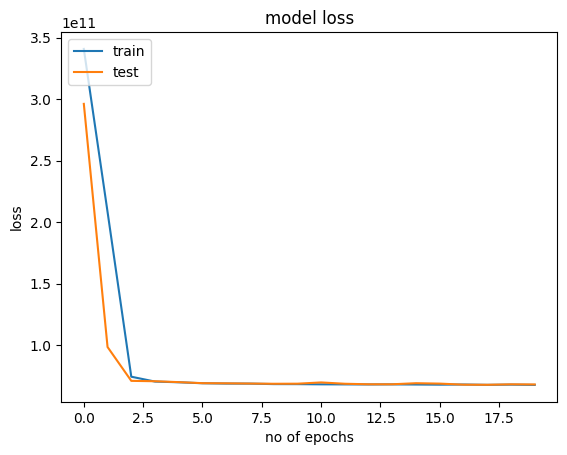

In [122]:
#plotting the training
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('no of epochs')
plt.legend(['train','test'],loc='upper left')
plt.show()


In [123]:
#predicting the house price for a single house
import numpy
from numpy import array

#the input data for getting the price
Xnew = numpy.array([[2,3,1280,5550,1,0,0,4,7,2280,0,1440,5750,60]])
#convert the values in the arry to float
Xnew = numpy.array(Xnew, dtype=numpy.float64)

#making the prediction
Ynew = model.predict(Xnew)

#print the prediction
print(Ynew[0])

1/1 [==============================] - 0s 112ms/step
[469933.2]
